## 13. Arquitectura Propuesta: Dual-Branch Fusion Network (DBFNet)

### Motivación

Los experimentos anteriores muestran que:
1. La capa 0 de Wav2Vec2 (acústica temporal) y ResNet18 (espectral) capturan información complementaria
2. La fusión por concatenación+PCA+SVM alcanza AUC=0.905 pero no aprende la ponderación óptima
3. La ponderación manual (spec×3.0) mejora, pero es estática para todos los sujetos

### Propuesta: Fusión con atención aprendida

Red de dos ramas con extractores congelados y un módulo de atención ligero:

- **Rama temporal**: Wav2Vec2 capa 0 (congelado) → proyección 768→128
- **Rama espectral**: ResNet18/mel-spec (congelado) → proyección 512→128
- **Módulo de fusión**: Gated attention que aprende α ∈ [0,1] por muestra:

$$\mathbf{z}_{\text{fusion}} = \alpha \cdot \mathbf{z}_{\text{temp}} + (1-\alpha) \cdot \mathbf{z}_{\text{spec}}$$

$$\alpha = \sigma(\mathbf{w}^T [\mathbf{z}_{\text{temp}} \| \mathbf{z}_{\text{spec}}] + b)$$

### Parámetros entrenables

Solo las proyecciones + gate + clasificador final: ~35K parámetros.
Los backbones (Wav2Vec2: 95M, ResNet18: 11M) están completamente congelados.

In [3]:
from src.models import DualBranchFusionNet

model_test = DualBranchFusionNet()
total_params = sum(p.numel() for p in model_test.parameters())
trainable_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f"Parámetros totales:     {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")

%load_ext autoreload
%autoreload 2

Parámetros totales:     205,954
Parámetros entrenables: 205,954


### Preprocesamiento

In [5]:
from src.preprocessing import load_waveforms, preprocess_waveform, load_metadata
import torch

TARGET_SR = 16_000
LAYERS_TO_EXTRACT = [0, 3, 7, 11]
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
RANDOM_STATE = 42
N_FOLDS = 5

df_metadata = load_metadata(base_path="data")
waveforms_raw, df_metadata = load_waveforms(df_metadata, target_sr=TARGET_SR)
waveforms_processed = [preprocess_waveform(wf) for wf in waveforms_raw]

In [6]:
from src.embeddings import extract_multilayer_embeddings

w2v_layers = extract_multilayer_embeddings(
    waveforms_processed, "facebook/wav2vec2-base", LAYERS_TO_EXTRACT, DEVICE
)

hubert_layers = extract_multilayer_embeddings(
    waveforms_processed, "facebook/hubert-base-ls960", LAYERS_TO_EXTRACT, DEVICE
)

emb_w2v_L0 = w2v_layers[0]
emb_hubert_L0 = hubert_layers[0]

2026-03-22 20:55:10,384 [INFO] src.config:   Cargando facebook/wav2vec2-base...
2026-03-22 20:55:10,934 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-22 20:55:11,029 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/wav2vec2-base/0b5b8e868dd84f03fd87d01f9c4ff0f080fecfe8/config.json "HTTP/1.1 200 OK"
2026-03-22 20:55:11,138 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-03-22 20:55:11,244 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-03-22 20:55:11,358 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/pytorch_model.bin "HTTP/1.1 302 Found"
2026-03-22 20:55:11,464 [INFO] httpx: HTTP Request: HEAD https://huggingfac

  25/100
  50/100
  75/100


2026-03-22 20:55:17,929 [INFO] src.config:   Cargando facebook/hubert-base-ls960...


  100/100


2026-03-22 20:55:18,369 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/hubert-base-ls960/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-22 20:55:18,465 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/hubert-base-ls960/dba3bb02fda4248b6e082697eee756de8fe8aa8a/config.json "HTTP/1.1 200 OK"
2026-03-22 20:55:18,574 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/hubert-base-ls960/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-03-22 20:55:18,682 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/hubert-base-ls960/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-03-22 20:55:18,800 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/hubert-base-ls960/resolve/main/pytorch_model.bin "HTTP/1.1 302 Found"
2026-03-22 20:55:18,908 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/hubert-base-ls960/resolve/main/model.safetenso

  25/100
  50/100
  75/100
  100/100


In [7]:
from src.spectral import extract_spectral_features

MEL_CONFIG = {
    "sample_rate": TARGET_SR,
    "n_fft": 1024,        # Resolución frecuencial: Δf ≈ 15.6 Hz
    "hop_length": 512,    # 50% overlap entre ventanas STFT
    "n_mels": 128,        # 128 bandas mel
}

spectral_features = extract_spectral_features(
    waveforms_processed,
    device=DEVICE,
    **MEL_CONFIG,
)

2026-03-22 20:55:24,201 [INFO] src.config: Generando mel-espectrogramas...
2026-03-22 20:55:24,299 [INFO] src.config:   100 espectrogramas generados
2026-03-22 20:55:24,299 [INFO] src.config:   Shape ejemplo: (128, 107)
2026-03-22 20:55:24,300 [INFO] src.config: Extrayendo features con ResNet18 (ImageNet)...
2026-03-22 20:55:24,684 [INFO] src.config:   25/100
2026-03-22 20:55:24,760 [INFO] src.config:   50/100
2026-03-22 20:55:24,828 [INFO] src.config:   75/100
2026-03-22 20:55:24,898 [INFO] src.config:   100/100
2026-03-22 20:55:24,899 [INFO] src.config:   Features espectrales: (100, 512)


### Entrenamiento

In [8]:
from src.datasets import DualBranchDataset
from src.training import train_dbfnet_fold, StratifiedKFold
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, recall_score
import numpy as np

# -------------------------------------------------------
# K-Fold CV
# -------------------------------------------------------
# Normalizar embeddings antes (como hacemos con PCA+SVM)
from sklearn.preprocessing import StandardScaler

scaler_t = StandardScaler()
scaler_s = StandardScaler()
emb_t_norm = scaler_t.fit_transform(emb_w2v_L0)
emb_s_norm = scaler_s.fit_transform(spectral_features)

labels_arr = df_metadata["label"].to_numpy()
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

LR_OPTIONS = [5e-4, 1e-3, 2e-3]
BS_OPTIONS = [8, 16]

print("DBFNet: Dual-Branch Fusion Network")
print("="*65)

best_dbf_auc = -1
best_dbf = None

for lr in LR_OPTIONS:
    for bs in BS_OPTIONS:
        fold_aucs, fold_accs, fold_sens, fold_spec, fold_alphas = [], [], [], [], []

        for fold_idx, (train_idx, val_idx) in enumerate(skf.split(emb_t_norm, labels_arr)):
            train_ds = DualBranchDataset(emb_t_norm, emb_s_norm, labels_arr, train_idx)
            val_ds = DualBranchDataset(emb_t_norm, emb_s_norm, labels_arr, val_idx)

            y_true, y_prob, alphas = train_dbfnet_fold(
                train_ds, val_ds, DEVICE, lr=lr, epochs=100, patience=15, batch_size=bs
            )

            fpr, tpr, thresholds = roc_curve(y_true, y_prob)
            best_thr = thresholds[np.argmax(tpr - fpr)]
            y_pred = (y_prob >= best_thr).astype(int)

            fold_aucs.append(roc_auc_score(y_true, y_prob))
            fold_accs.append(accuracy_score(y_true, y_pred))
            fold_sens.append(recall_score(y_true, y_pred, pos_label=1, zero_division=0))
            fold_spec.append(recall_score(y_true, y_pred, pos_label=0, zero_division=0))
            fold_alphas.append(alphas.mean())

        mean_auc = np.mean(fold_aucs)
        mean_acc = np.mean(fold_accs)
        mean_alpha = np.mean(fold_alphas)

        marker = " 🎯" if mean_acc >= 0.90 else ""
        print(f"  lr={lr:.0e} bs={bs}  →  AUC={mean_auc:.3f}  Acc={mean_acc:.3f}  "
              f"Sens={np.mean(fold_sens):.3f}  Spec={np.mean(fold_spec):.3f}  "
              f"α={mean_alpha:.2f}{marker}")

        if mean_auc > best_dbf_auc:
            best_dbf_auc = mean_auc
            best_dbf = {
                "lr": lr, "bs": bs,
                "auc_mean": mean_auc,               "auc_std": np.std(fold_aucs),
                "acc_mean": mean_acc,                "acc_std": np.std(fold_accs),
                "sens_mean": np.mean(fold_sens),     "sens_std": np.std(fold_sens),
                "spec_mean": np.mean(fold_spec),     "spec_std": np.std(fold_spec),
                "alpha_mean": mean_alpha,
            }

print(f"\n  ✅ Mejor DBFNet:")
print(f"     lr={best_dbf['lr']:.0e}  bs={best_dbf['bs']}")
print(f"     AUC:  {best_dbf['auc_mean']:.3f} ± {best_dbf['auc_std']:.3f}")
print(f"     Acc:  {best_dbf['acc_mean']:.3f} ± {best_dbf['acc_std']:.3f}")
print(f"     Sens: {best_dbf['sens_mean']:.3f} ± {best_dbf['sens_std']:.3f}")
print(f"     Spec: {best_dbf['spec_mean']:.3f} ± {best_dbf['spec_std']:.3f}")
print(f"     α medio: {best_dbf['alpha_mean']:.3f} (>0.5 = más temporal, <0.5 = más espectral)")

DBFNet: Dual-Branch Fusion Network
  lr=5e-04 bs=8  →  AUC=0.916  Acc=0.900  Sens=0.860  Spec=0.940  α=0.78 🎯
  lr=5e-04 bs=16  →  AUC=0.900  Acc=0.890  Sens=0.820  Spec=0.960  α=0.72
  lr=1e-03 bs=8  →  AUC=0.936  Acc=0.910  Sens=0.900  Spec=0.920  α=0.74 🎯
  lr=1e-03 bs=16  →  AUC=0.918  Acc=0.910  Sens=0.880  Spec=0.940  α=0.73 🎯
  lr=2e-03 bs=8  →  AUC=0.880  Acc=0.880  Sens=0.840  Spec=0.920  α=0.63
  lr=2e-03 bs=16  →  AUC=0.924  Acc=0.920  Sens=0.860  Spec=0.980  α=0.71 🎯

  ✅ Mejor DBFNet:
     lr=1e-03  bs=8
     AUC:  0.936 ± 0.048
     Acc:  0.910 ± 0.037
     Sens: 0.900 ± 0.000
     Spec: 0.920 ± 0.075
     α medio: 0.744 (>0.5 = más temporal, <0.5 = más espectral)


### Evaluación

#### Coeficiente de validacion de Pearson

In [9]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, roc_curve

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

fold_aucs, fold_accs, fold_sens, fold_spec = [], [], [], []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(emb_t_norm, labels_arr)):
    train_ds = DualBranchDataset(emb_t_norm, emb_s_norm, labels_arr, train_idx)
    val_ds = DualBranchDataset(emb_t_norm, emb_s_norm, labels_arr, val_idx)

    y_true, y_prob, alphas = train_dbfnet_fold(
        train_ds, val_ds, DEVICE, lr=5e-4, epochs=100, patience=15, batch_size=8
    )

    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    best_thr = thresholds[np.argmax(tpr - fpr)]
    y_pred = (y_prob >= best_thr).astype(int)

    auc_val = roc_auc_score(y_true, y_prob)
    acc_val = accuracy_score(y_true, y_pred)
    sens_val = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    spec_val = recall_score(y_true, y_pred, pos_label=0, zero_division=0)

    fold_aucs.append(auc_val)
    fold_accs.append(acc_val)
    fold_sens.append(sens_val)
    fold_spec.append(spec_val)

    print(f"  Fold {fold_idx+1}: AUC={auc_val:.3f}  Acc={acc_val:.3f}  Sens={sens_val:.3f}  Spec={spec_val:.3f}")

# Calcular CV de Pearson
print(f"\n{'='*65}")
print(f"  COEFICIENTE DE VARIACIÓN DE PEARSON (CV%)")
print(f"  CV = (σ / μ) × 100 — menor = más estable")
print(f"{'='*65}")

for metric_name, values in [("AUC", fold_aucs), ("Accuracy", fold_accs),
                             ("Sensibilidad", fold_sens), ("Especificidad", fold_spec)]:
    mean = np.mean(values)
    std = np.std(values)
    cv = (std / mean) * 100 if mean > 0 else float('inf')
    print(f"  {metric_name:<15}  μ={mean:.3f}  σ={std:.3f}  CV={cv:.1f}%")
    print(f"    Folds: {[f'{v:.3f}' for v in values]}")

  Fold 1: AUC=0.980  Acc=0.950  Sens=1.000  Spec=0.900
  Fold 2: AUC=0.830  Acc=0.900  Sens=0.800  Spec=1.000
  Fold 3: AUC=0.780  Acc=0.750  Sens=0.600  Spec=0.900
  Fold 4: AUC=0.970  Acc=0.950  Sens=1.000  Spec=0.900
  Fold 5: AUC=1.000  Acc=1.000  Sens=1.000  Spec=1.000

  COEFICIENTE DE VARIACIÓN DE PEARSON (CV%)
  CV = (σ / μ) × 100 — menor = más estable
  AUC              μ=0.912  σ=0.089  CV=9.8%
    Folds: ['0.980', '0.830', '0.780', '0.970', '1.000']
  Accuracy         μ=0.910  σ=0.086  CV=9.5%
    Folds: ['0.950', '0.900', '0.750', '0.950', '1.000']
  Sensibilidad     μ=0.880  σ=0.160  CV=18.2%
    Folds: ['1.000', '0.800', '0.600', '1.000', '1.000']
  Especificidad    μ=0.940  σ=0.049  CV=5.2%
    Folds: ['0.900', '1.000', '0.900', '0.900', '1.000']


#### Curvas de pérdida

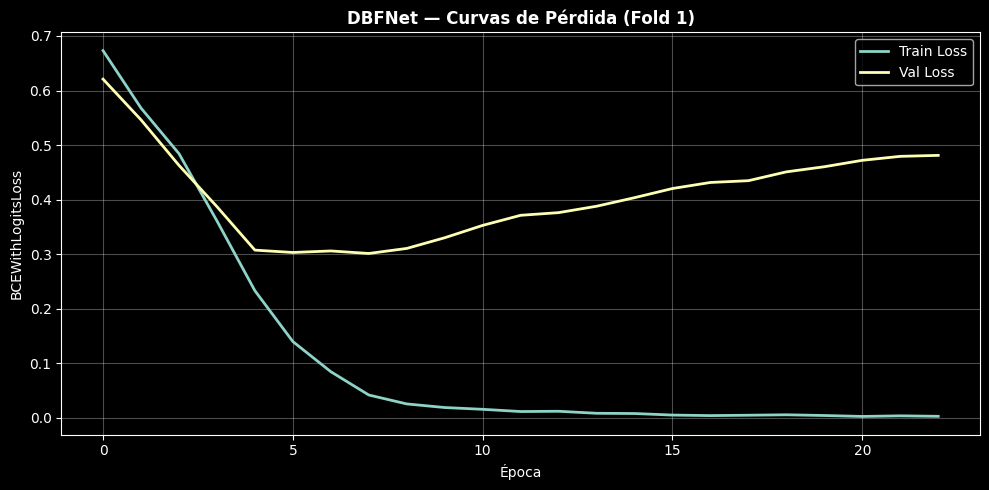

Épocas entrenadas: 23
Train loss final: 0.0027
Val loss mínima: 0.3013


In [10]:
from src.training import train_dbfnet_fold_with_history
import matplotlib.pyplot as plt


# Ejecutar un fold con historial para visualizar
train_idx_demo, val_idx_demo = list(skf.split(emb_t_norm, labels_arr))[0]
train_ds_demo = DualBranchDataset(emb_t_norm, emb_s_norm, labels_arr, train_idx_demo)
val_ds_demo = DualBranchDataset(emb_t_norm, emb_s_norm, labels_arr, val_idx_demo)

y_true_demo, y_prob_demo, alphas_demo, history_demo = train_dbfnet_fold_with_history(
    train_ds_demo, val_ds_demo, DEVICE, lr=5e-4, epochs=100, patience=15, batch_size=8
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history_demo["train_loss"], label="Train Loss", linewidth=2)
ax.plot(history_demo["val_loss"], label="Val Loss", linewidth=2)
ax.set_xlabel("Época")
ax.set_ylabel("BCEWithLogitsLoss")
ax.set_title("DBFNet — Curvas de Pérdida (Fold 1)", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Épocas entrenadas: {len(history_demo['train_loss'])}")
print(f"Train loss final: {history_demo['train_loss'][-1]:.4f}")
print(f"Val loss mínima: {min(history_demo['val_loss']):.4f}")

#### Validación de curvas de pérdida por folds

  Fold 1: 23 épocas, train_loss_final=0.0028, val_loss_min=0.2957
  Fold 2: 19 épocas, train_loss_final=0.0049, val_loss_min=0.5690
  Fold 3: 19 épocas, train_loss_final=0.0049, val_loss_min=0.5883
  Fold 4: 34 épocas, train_loss_final=0.0015, val_loss_min=0.1600
  Fold 5: 21 épocas, train_loss_final=0.0033, val_loss_min=0.3461


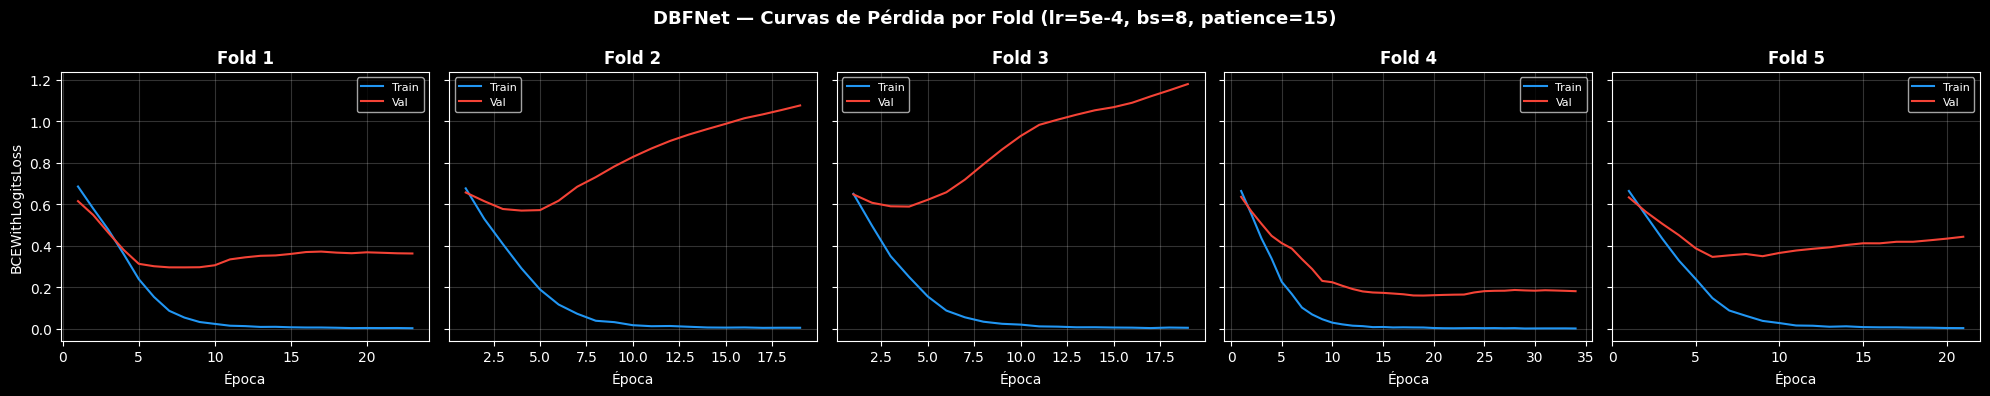

In [11]:
# ============================================================
# CURVAS DE PÉRDIDA — DBFNet (5 Folds)
# ============================================================

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

all_histories = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(emb_t_norm, labels_arr)):
    train_ds = DualBranchDataset(emb_t_norm, emb_s_norm, labels_arr, train_idx)
    val_ds = DualBranchDataset(emb_t_norm, emb_s_norm, labels_arr, val_idx)

    _, _, _, history = train_dbfnet_fold_with_history(
        train_ds, val_ds, DEVICE, lr=5e-4, epochs=100, patience=15, batch_size=8
    )
    all_histories.append(history)
    print(f"  Fold {fold_idx+1}: {len(history['train_loss'])} épocas, "
          f"train_loss_final={history['train_loss'][-1]:.4f}, "
          f"val_loss_min={min(history['val_loss']):.4f}")

# -------------------------------------------------------
# Gráfica
# -------------------------------------------------------
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for i, (ax, hist) in enumerate(zip(axes, all_histories)):
    epochs = range(1, len(hist["train_loss"]) + 1)
    ax.plot(epochs, hist["train_loss"], label="Train", linewidth=1.5, color="#2196F3")
    ax.plot(epochs, hist["val_loss"], label="Val", linewidth=1.5, color="#F44336")
    ax.set_title(f"Fold {i+1}", fontweight="bold")
    ax.set_xlabel("Época")
    ax.grid(True, alpha=0.2)
    if i == 0:
        ax.set_ylabel("BCEWithLogitsLoss")
    ax.legend(fontsize=8)

plt.suptitle("DBFNet — Curvas de Pérdida por Fold (lr=5e-4, bs=8, patience=15)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()